In [5]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification, make_regression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, mean_squared_error, r2_score, classification_report
import warnings
warnings.filterwarnings('ignore')

# 시드 고정 (재현성)
np.random.seed(42)

In [6]:
X_clf, y_clf = make_classification(
    n_samples=400, n_features=2, random_state=42,
    n_informative=2, n_redundant=0,n_clusters_per_class=1,class_sep=1.5
    )
scaler = StandardScaler()
# 데이터 분할 train - test 8:2
x_train,x_test,y_train,y_test = train_test_split(X_clf,y_clf,random_state=42, stratify=y_clf,test_size=0.2)
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)
# pytorch 텐서로 변환
x_train_t = torch.tensor(x_train,dtype=torch.float32)
y_train_t = torch.FloatTensor(y_train)
x_test_t = torch.FloatTensor(x_test)
y_test_t = torch.FloatTensor(y_test)

In [7]:
# 분류모델 정의
class BinaryClassifier(nn.Module):
  def __init__(self) -> None:
    super().__init__()
    self.fc1 = nn.Linear( 2 , 16)
    self.relu = nn.ReLU()
    self.fc2 = nn.Linear(16 ,1 )    
  def forward(self, x):    
    x = self.relu( self.fc1(x) )    
    output = self.fc2(x) 
    return output
model = BinaryClassifier()    
model

BinaryClassifier(
  (fc1): Linear(in_features=2, out_features=16, bias=True)
  (relu): ReLU()
  (fc2): Linear(in_features=16, out_features=1, bias=True)
)

In [8]:
criterion = nn.BCEWithLogitsLoss()
optimizer = optim.SGD(model.parameters(), lr=0.01,momentum=0)
x_train_dataset = TensorDataset(x_train_t, y_train_t)
x_train_loader = DataLoader(x_train_dataset,batch_size=1,shuffle=True)

In [9]:
# 훈련루프
from tqdm import tqdm
epochs = 100
train_losses , train_accs = [], []
for epoch in tqdm(range(epochs)):
  total_loss, total_acc = 0.0 , 0.0
  for x,y in x_train_loader:
    # 가중치 초기화
    optimizer.zero_grad()
    # forward
    predict = model(x).squeeze(1)
    # loss 구하고        
    loss = criterion(predict,y)
    # backward
    loss.backward()
    # 가중치 업데이트
    optimizer.step()

    total_loss += loss.item()    
    
    predict = 1 if torch.sigmoid(predict)>=0.5 else 0
    total_acc += int(predict == int(y.item()))
  train_losses.append( total_loss / len(x_train_loader) )
  train_accs.append( total_acc / len(x_train_loader) )


100%|██████████| 100/100 [00:12<00:00,  8.26it/s]


Text(0.5, 1.0, '0.959375')

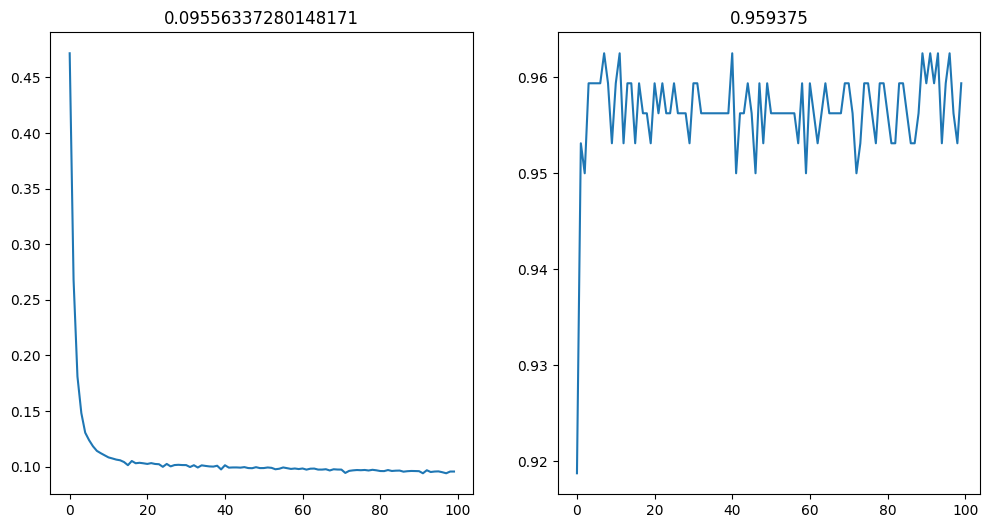

In [10]:
fig,ax = plt.subplots(1,2,figsize=(12,6))

ax[0].plot(range(epochs),train_losses)
ax[0].set_title(train_losses[-1])
ax[1].plot(range(epochs),train_accs)
ax[1].set_title(train_accs[-1])

In [11]:
# 평가
with torch.no_grad():
  predict = model(x_test_t).squeeze(1)  
  loss = criterion(predict, y_test_t)

  predict = (torch.sigmoid(predict) >= 0.5).float()
  print(f'{loss:.4f}')
  print(accuracy_score(y_test_t, predict))

0.1639
0.9375


# 회귀

In [12]:
# 회귀 데이터 생성
X_reg, y_reg = make_regression(
    n_samples=300,
    n_features=5,
    n_informative=5,
    noise=20.0,
    random_state=42
)

# 데이터 정규화
scaler_X_reg = StandardScaler()
X_reg = scaler_X_reg.fit_transform(X_reg)

scaler_y_reg = StandardScaler()
y_reg = scaler_y_reg.fit_transform(y_reg.reshape(-1, 1)).flatten()

# 학습/테스트 분할 (80/20)
X_reg_train, X_reg_test, y_reg_train, y_reg_test = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=42
)

# PyTorch 텐서로 변환
X_reg_train_tensor = torch.FloatTensor(X_reg_train)
y_reg_train_tensor = torch.FloatTensor(y_reg_train).reshape(-1, 1)
X_reg_test_tensor = torch.FloatTensor(X_reg_test)
y_reg_test_tensor = torch.FloatTensor(y_reg_test).reshape(-1, 1)

print(f"회귀 데이터셋 생성 완료")
print(f"훈련 데이터: {X_reg_train_tensor.shape}")
print(f"테스트 데이터: {X_reg_test_tensor.shape}")
print(f"목표값 범위: [{y_reg.min():.4f}, {y_reg.max():.4f}]")

회귀 데이터셋 생성 완료
훈련 데이터: torch.Size([240, 5])
테스트 데이터: torch.Size([60, 5])
목표값 범위: [-2.4866, 2.6997]


# 모델정의

# SGD 설정 및 훈련

In [14]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import mean_squared_error, r2_score

# 1. 예시 데이터 생성 (이미 데이터가 있다면 이 부분은 건너뛰어도 됩니다)
# X_reg_train_tensor, y_reg_train_tensor 등이 정의되어 있어야 합니다.
if 'X_reg_train_tensor' not in locals():
    print("예시 데이터를 생성합니다.")
    X_reg_train = np.random.rand(100, 1).astype(np.float32)
    y_reg_train = 3 * X_reg_train + 2 + np.random.randn(100, 1).astype(np.float32) * 0.1
    X_reg_test = np.random.rand(20, 1).astype(np.float32)
    y_reg_test = 3 * X_reg_test + 2 + np.random.randn(20, 1).astype(np.float32) * 0.1

    X_reg_train_tensor = torch.from_numpy(X_reg_train)
    y_reg_train_tensor = torch.from_numpy(y_reg_train)
    X_reg_test_tensor = torch.from_numpy(X_reg_test)
    y_reg_test_tensor = torch.from_numpy(y_reg_test)

# 2. 모델 클래스 정의
class RegressionModel(nn.Module):
    def __init__(self, input_dim):
        super(RegressionModel, self).__init__()
        self.linear = nn.Linear(input_dim, 1)
        
    def forward(self, x):
        return self.linear(x)

# 3. 모델 인스턴스 생성 및 최적화기 설정
input_dim = X_reg_train_tensor.shape[1]
model_reg = RegressionModel(input_dim)

criterion_reg = nn.MSELoss()  # 회귀 손실함수: MSE
optimizer_sgd_reg = optim.SGD(model_reg.parameters(), lr=0.01, momentum=0)

# 4. DataLoader 설정 (batch_size=1은 순수 SGD 방식)
reg_dataset = TensorDataset(X_reg_train_tensor, y_reg_train_tensor)
reg_loader = DataLoader(reg_dataset, batch_size=1, shuffle=True)

# 5. 훈련 루프
num_epochs = 150
train_losses_reg = []
train_r2_scores = []

print("훈련 시작...")
for epoch in range(num_epochs):
    total_loss = 0
    all_predictions = []
    all_targets = []
    
    for X_batch, y_batch in reg_loader:
        # --- Forward pass ---
        outputs = model_reg(X_batch)
        loss = criterion_reg(outputs, y_batch)
        
        # --- Backward pass + SGD 업데이트 ---
        optimizer_sgd_reg.zero_grad()  # 기울기 초기화
        loss.backward()               # 역전파
        optimizer_sgd_reg.step()       # 가중치 업데이트
        
        total_loss += loss.item() * X_batch.size(0)
        
        # R² 점수 계산을 위한 데이터 수집
        with torch.no_grad():
            all_predictions.append(outputs.item())
            all_targets.append(y_batch.item())
    
    avg_loss = total_loss / len(reg_loader.dataset)
    r2 = r2_score(all_targets, all_predictions)
    train_losses_reg.append(avg_loss)
    train_r2_scores.append(r2)
    
    if (epoch + 1) % 30 == 0:
        print(f"Epoch [{epoch+1}/{num_epochs}] Loss: {avg_loss:.4f}, R²: {r2:.4f}")

print("회귀 모델 훈련 완료!")

# 6. 테스트 데이터에 대한 평가
model_reg.eval() # 평가 모드 전환
with torch.no_grad():
    y_pred_reg = model_reg(X_reg_test_tensor)
    
    # 텐서를 넘파이 배열로 변환 (CPU로 옮긴 후 변환하는 것이 안전)
    y_true_np = y_reg_test_tensor.cpu().numpy()
    y_pred_np = y_pred_reg.cpu().numpy()
    
    test_mse = mean_squared_error(y_true_np, y_pred_np)
    test_r2 = r2_score(y_true_np, y_pred_np)
    test_rmse = np.sqrt(test_mse)

print("\n[회귀 문제 결과]")
print(f"테스트 MSE: {test_mse:.4f}")
print(f"테스트 RMSE: {test_rmse:.4f}")
print(f"테스트 R²: {test_r2:.4f}")

훈련 시작...
Epoch [30/150] Loss: 0.0355, R²: 0.9652
Epoch [60/150] Loss: 0.0360, R²: 0.9647
Epoch [90/150] Loss: 0.0352, R²: 0.9654
Epoch [120/150] Loss: 0.0352, R²: 0.9655
Epoch [150/150] Loss: 0.0356, R²: 0.9651
회귀 모델 훈련 완료!

[회귀 문제 결과]
테스트 MSE: 0.0388
테스트 RMSE: 0.1969
테스트 R²: 0.9579


# 회귀모델 평가

In [15]:
import torch
import numpy as np
from sklearn.metrics import mean_squared_error, r2_score

# 그 다음 기존 코드를 실행하세요
with torch.no_grad():
    y_pred_reg = model_reg(X_reg_test_tensor)
    # ... 나머지 코드

# 테스트 데이터에 대한 평가
with torch.no_grad():
    y_pred_reg = model_reg(X_reg_test_tensor)
    test_mse = mean_squared_error(y_reg_test_tensor.numpy(), y_pred_reg.numpy())
    test_r2 = r2_score(y_reg_test_tensor.numpy(), y_pred_reg.numpy())
    test_rmse = np.sqrt(test_mse)

print("\n[회귀 문제 결과]")
print(f"테스트 MSE: {test_mse:.4f}")
print(f"테스트 RMSE: {test_rmse:.4f}")
print(f"테스트 R²: {test_r2:.4f}")


[회귀 문제 결과]
테스트 MSE: 0.0388
테스트 RMSE: 0.1969
테스트 R²: 0.9579
